# Lab 4: Model-Based Offline Optimization

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [18]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [19]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)
    train_size = int(train_perc * num_samples)
    val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [20]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [21]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 596.5008, Val Loss: 563.3771
Epoch 20/100, Train Loss: 416.0663, Val Loss: 410.6620
Epoch 30/100, Train Loss: 336.0786, Val Loss: 329.4614
Epoch 40/100, Train Loss: 257.8200, Val Loss: 249.8386
Epoch 50/100, Train Loss: 206.0756, Val Loss: 202.2207
Epoch 60/100, Train Loss: 178.1398, Val Loss: 175.0325
Epoch 70/100, Train Loss: 161.6684, Val Loss: 156.4651
Epoch 80/100, Train Loss: 151.8275, Val Loss: 150.0811
Epoch 90/100, Train Loss: 145.8607, Val Loss: 161.0021
Epoch 100/100, Train Loss: 142.9219, Val Loss: 140.4463
Test Loss: 141.9052


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

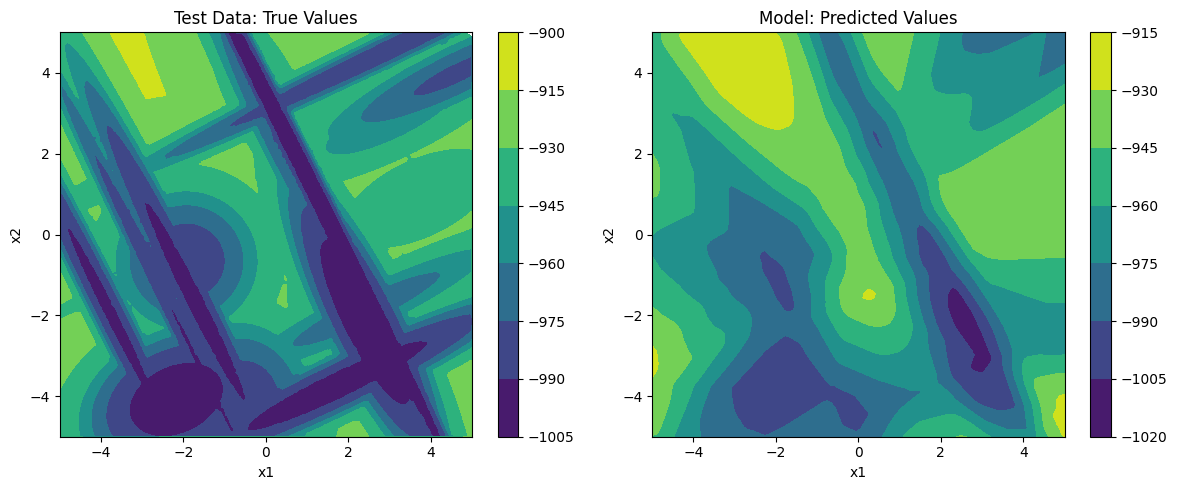

In [22]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device, best_x_values: list = None
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    if best_x_values is not None:
        best_x_array = np.vstack(best_x_values)

        ax1.scatter(
            best_x_array[:, 0],
            best_x_array[:, 1],
            c="red",
            marker="x",
            label="Optima",
            s=100
        )
        ax1.legend()

        ax2.scatter(
            best_x_array[:, 0],
            best_x_array[:, 1],
            c="red",
            marker="x",
            label="Optima",
            s=100
        )
        ax2.legend()

    plt.tight_layout()
    plt.show()

plot_contour_comparison(model, test_dataloader, device)

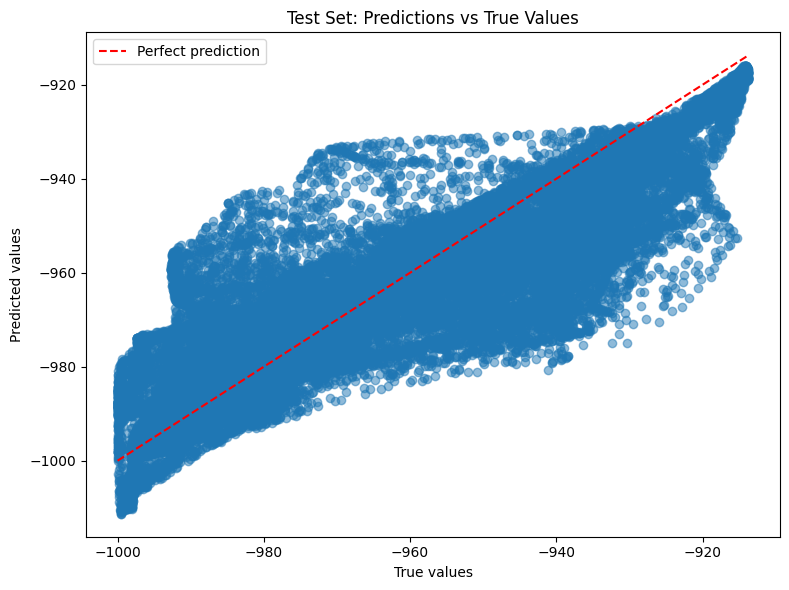

In [23]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [24]:
from torch.optim import Adam

def optimize_model(
    model: nn.Module, num_steps: int = 1000
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()
    # Select random starting point in [-5, 5]^2
    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)
    optimizer = Adam([x], lr=0.01)

    best_x = x.clone().detach()
    best_y = float("inf")

    for _ in range(num_steps):
        optimizer.zero_grad()
        # Predict output and compute loss to minimize
        outputs = model(x)
        loss = outputs.mean()

        # Compute gradients and update x
        loss.backward()
        optimizer.step()

        # Enforce domain constraints [-5, 5]
        with torch.no_grad():
            x.clamp_(-5, 5)

        # Track best solution found so far
        if loss.item() < best_y:
            best_y = loss.item()
            best_x = x.clone().detach()

    return best_x, best_y

## Exercise 1: Impact of Dataset Size

**Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).

**Instructions:**
1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
2. Train the model for each dataset size and generate corresponding contour plots.
3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
4. Select and justify a single quantitative metric that effectively captures the model's predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.



Scenario: Training with 100 samples
--------------------------------------------------
  Epoch  20: Train=874484.062500, Val=872622.222707
  Epoch  40: Train=763717.500000, Val=761941.746037
  Epoch  60: Train=572230.437500, Val=573536.617132
  Epoch  80: Train=332630.656250, Val=340888.982280
  Epoch 100: Train=141765.343750, Val=157039.597663
  Final RMSE: 396.308207



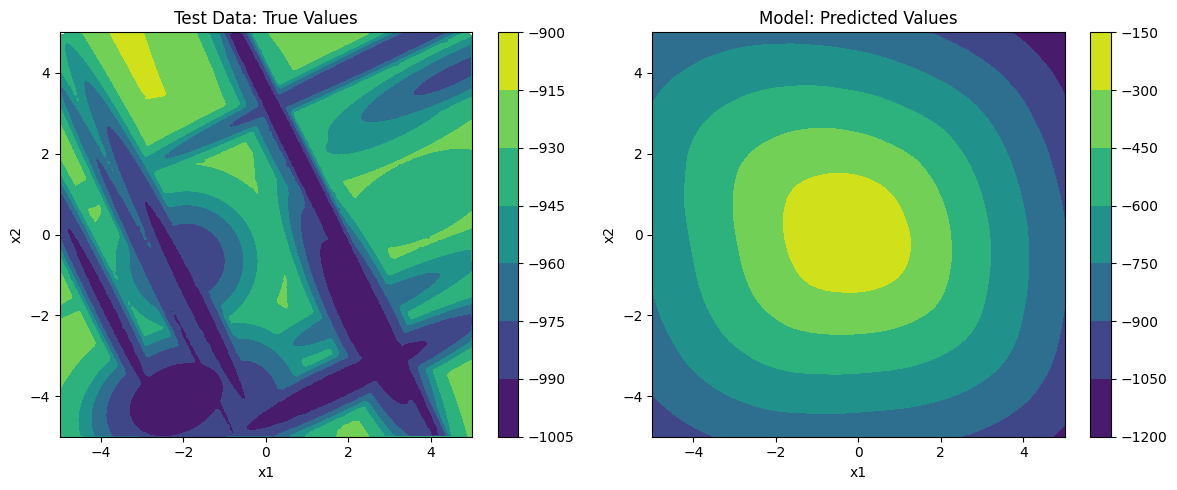

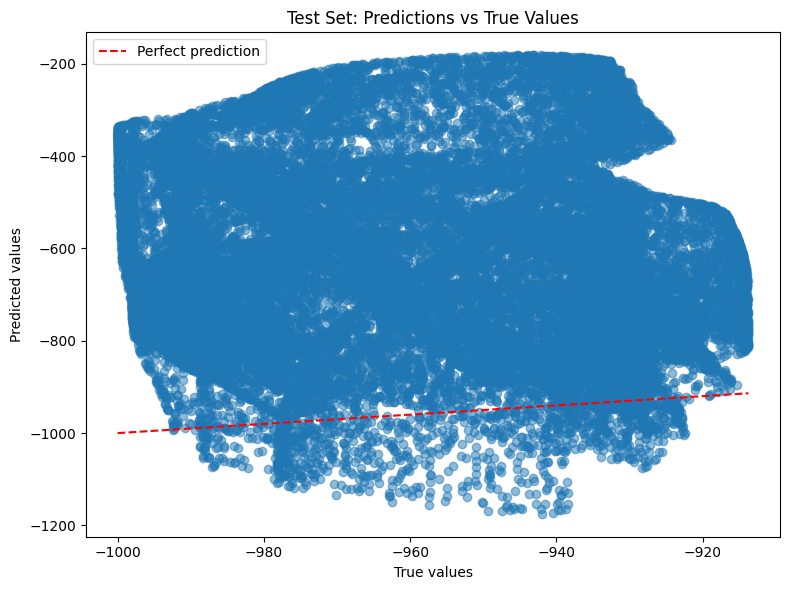


Scenario: Training with 1000 samples
--------------------------------------------------
  Epoch  20: Train=416923.139000, Val=387644.829123
  Epoch  40: Train=83889.760313, Val=77708.580135
  Epoch  60: Train=74542.899125, Val=69362.736241
  Epoch  80: Train=64162.430625, Val=59700.740932
  Epoch 100: Train=53097.817000, Val=49356.951961
  Final RMSE: 222.482124



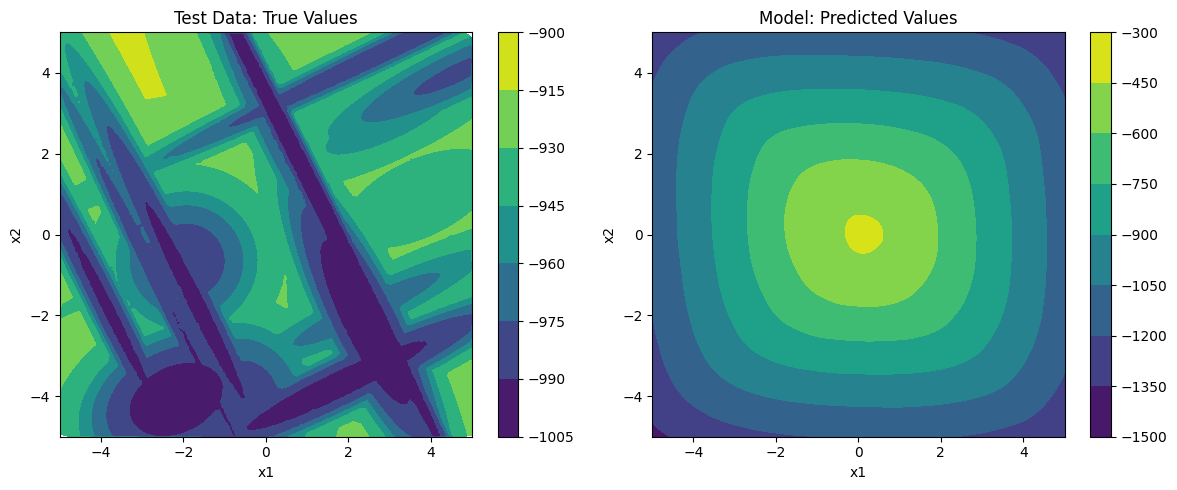

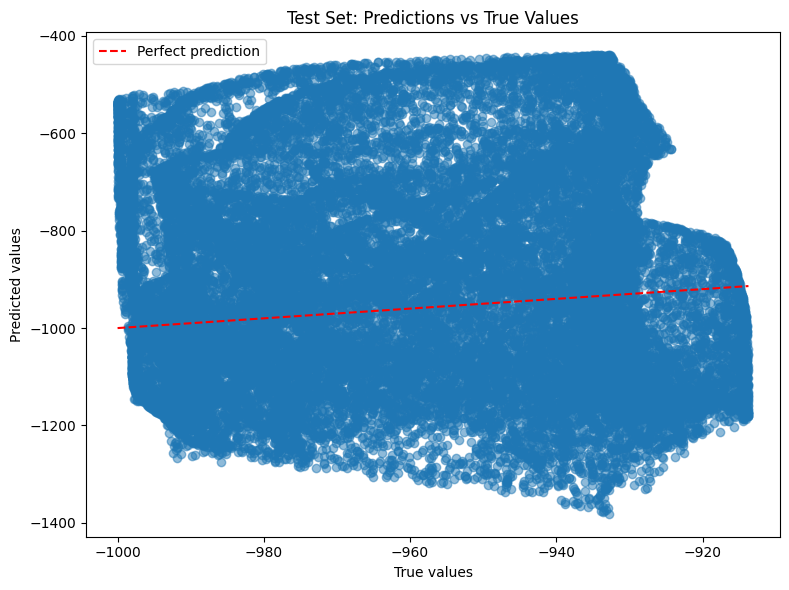


Scenario: Training with 5000 samples
--------------------------------------------------
  Epoch  20: Train=56277.881406, Val=54729.318642
  Epoch  40: Train=7387.469805, Val=6730.234141
  Epoch  60: Train=614.827860, Val=611.781295
  Epoch  80: Train=503.308274, Val=500.548835
  Epoch 100: Train=450.848711, Val=448.777537
  Final RMSE: 21.117479



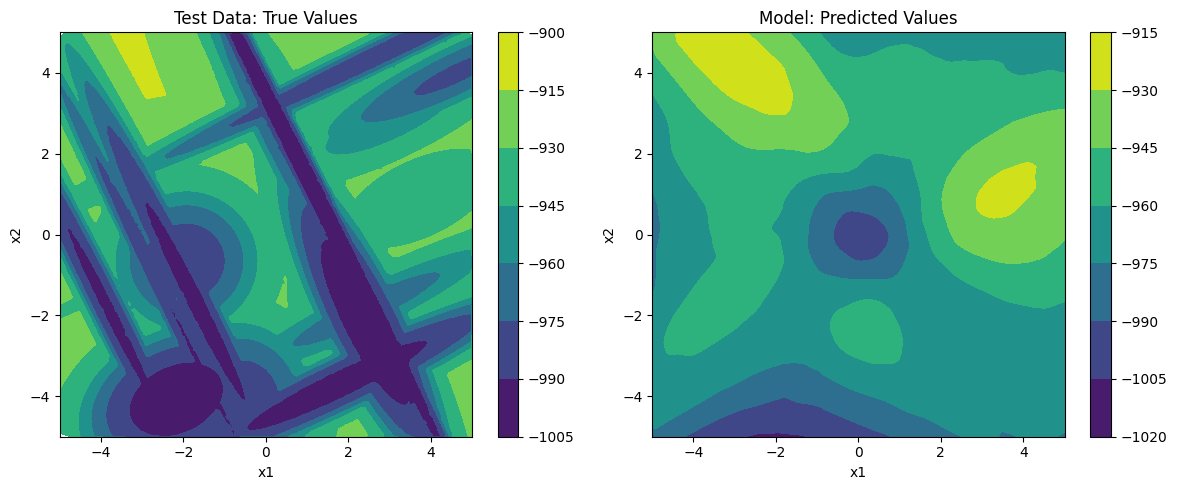

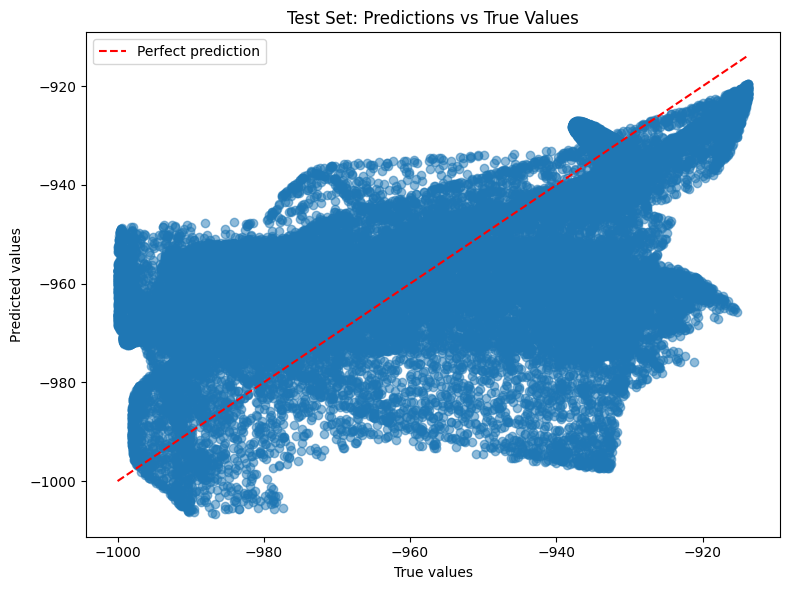


Scenario: Training with 10000 samples
--------------------------------------------------
  Epoch  20: Train=6848.555654, Val=5557.662287
  Epoch  40: Train=501.305267, Val=487.372465
  Epoch  60: Train=424.273794, Val=410.878349
  Epoch  80: Train=375.035867, Val=363.494732
  Epoch 100: Train=325.725457, Val=315.748557
  Final RMSE: 17.791940



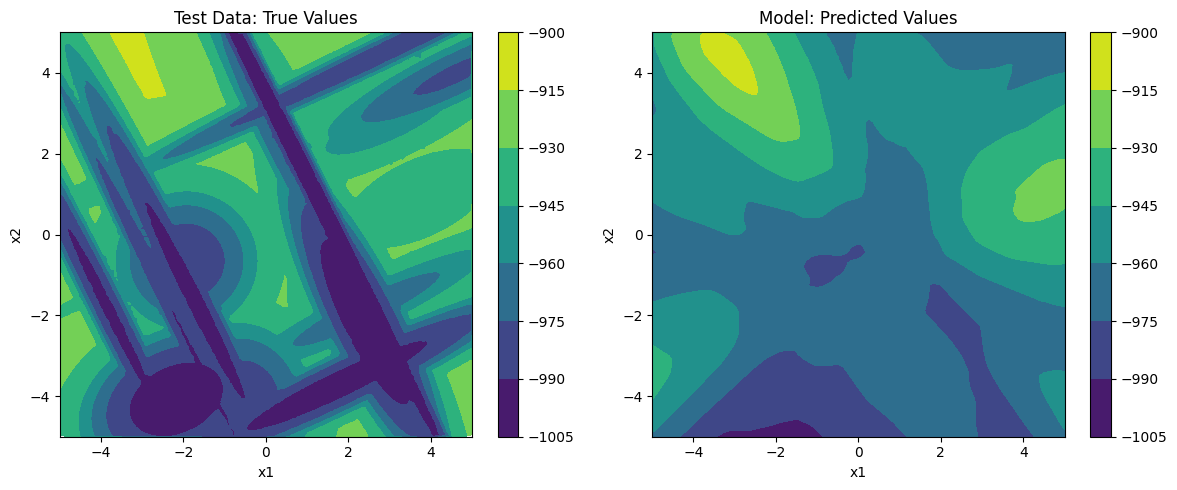

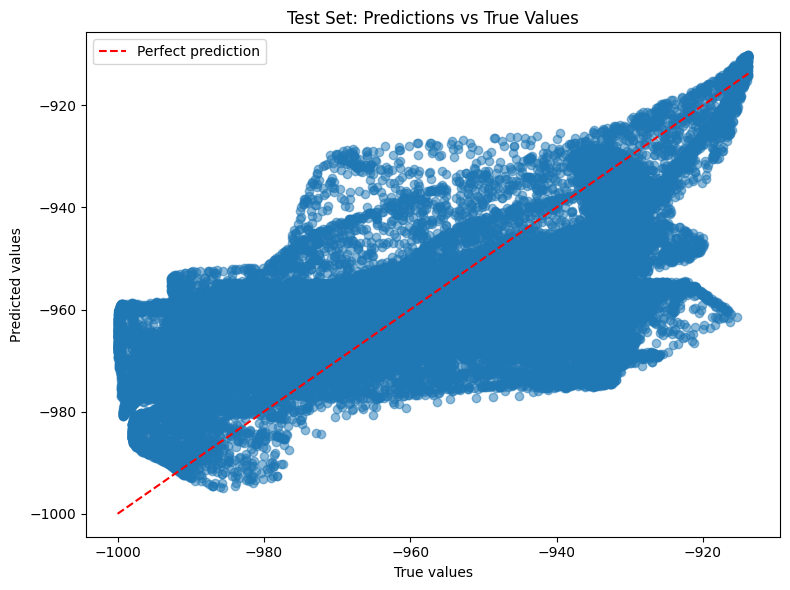


Scenario: Training with 50000 samples
--------------------------------------------------
  Epoch  20: Train=343.684032, Val=331.979258
  Epoch  40: Train=182.316081, Val=180.612870
  Epoch  60: Train=150.278719, Val=147.431966
  Epoch  80: Train=137.279125, Val=130.495601
  Epoch 100: Train=112.617853, Val=111.186908
  Final RMSE: 10.594098



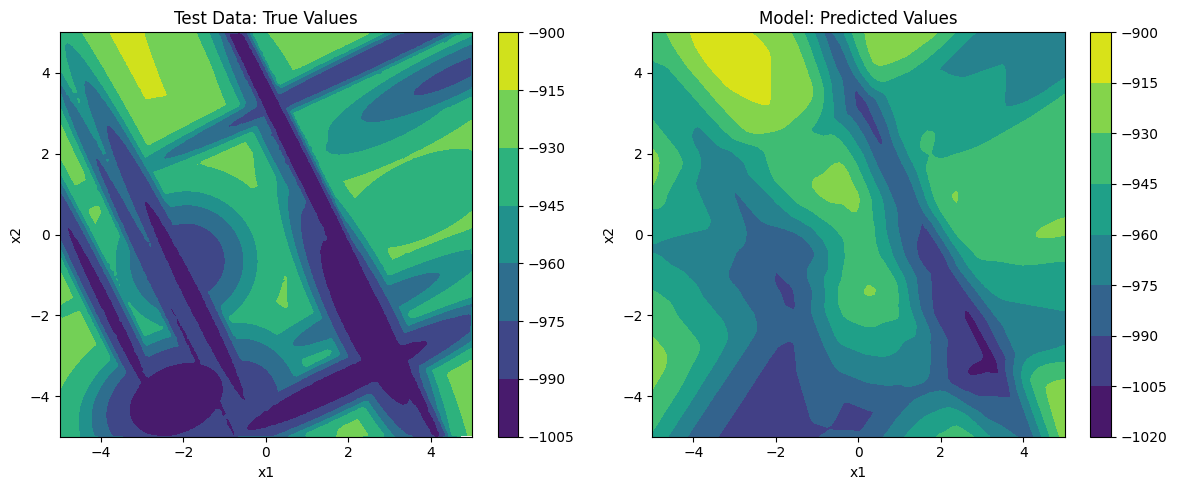

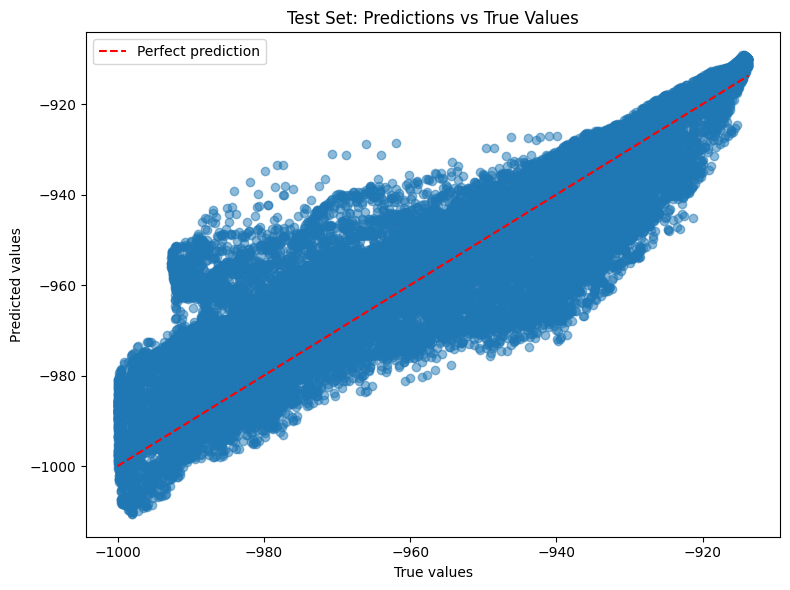

In [25]:
dataset_sizes = [100, 1_000, 5_000, 10_000, 50_000]
total_samples = 100_000
performance_scores = []

for current_size in dataset_sizes:
    perc = current_size / total_samples
    val_perc = 0.7 - perc
    
    print(f'\nScenario: Training with {current_size} samples')
    print('-' * 50)

    train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
        "./bbob_f022_i01_d02_samples.csv", 
        train_perc=perc, 
        val_perc=val_perc
    )

    surrogate_model = MLP().to(device)
    loss_fn = nn.MSELoss()
    param_optimizer = torch.optim.Adam(surrogate_model.parameters(), lr=0.001)
    epochs = 100

    train_error_history = []
    val_error_history = []

    for epoch in range(epochs):
        surrogate_model.train()
        accumulated_train_loss = 0.0
        
        for batch_inputs, batch_targets in train_dataloader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            param_optimizer.zero_grad()
            predictions = surrogate_model(batch_inputs)
            loss = loss_fn(predictions, batch_targets)
            loss.backward()
            param_optimizer.step()
            accumulated_train_loss += loss.item() * batch_inputs.size(0)

        accumulated_train_loss /= len(train_dataloader.dataset)
        train_error_history.append(accumulated_train_loss)
        
        surrogate_model.eval()
        accumulated_val_loss = 0.0
        with torch.no_grad():
            for batch_inputs, batch_targets in val_dataloader:
                batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
                predictions = surrogate_model(batch_inputs)
                loss = loss_fn(predictions, batch_targets)
                accumulated_val_loss += loss.item() * batch_inputs.size(0)
        
        accumulated_val_loss /= len(val_dataloader.dataset)
        val_error_history.append(accumulated_val_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}: Train={accumulated_train_loss:.6f}, Val={accumulated_val_loss:.6f}")

    surrogate_model.eval()
    mse_accumulator = 0.0
    num_test_samples = 0
    with torch.no_grad():
        for batch_inputs, batch_targets in test_dataloader:
            batch_inputs, batch_targets = batch_inputs.to(device), batch_targets.to(device)
            predictions = surrogate_model(batch_inputs)
            mse_accumulator += ((predictions - batch_targets) ** 2).sum().item()
            num_test_samples += batch_targets.size(0)
    
    rmse_score = (mse_accumulator / num_test_samples) ** 0.5
    performance_scores.append(rmse_score)
    
    print(f"  Final RMSE: {rmse_score:.6f}")
    print()
    plot_contour_comparison(surrogate_model, test_dataloader, device)
    plot_prediction_scatter(surrogate_model, test_dataloader, device)

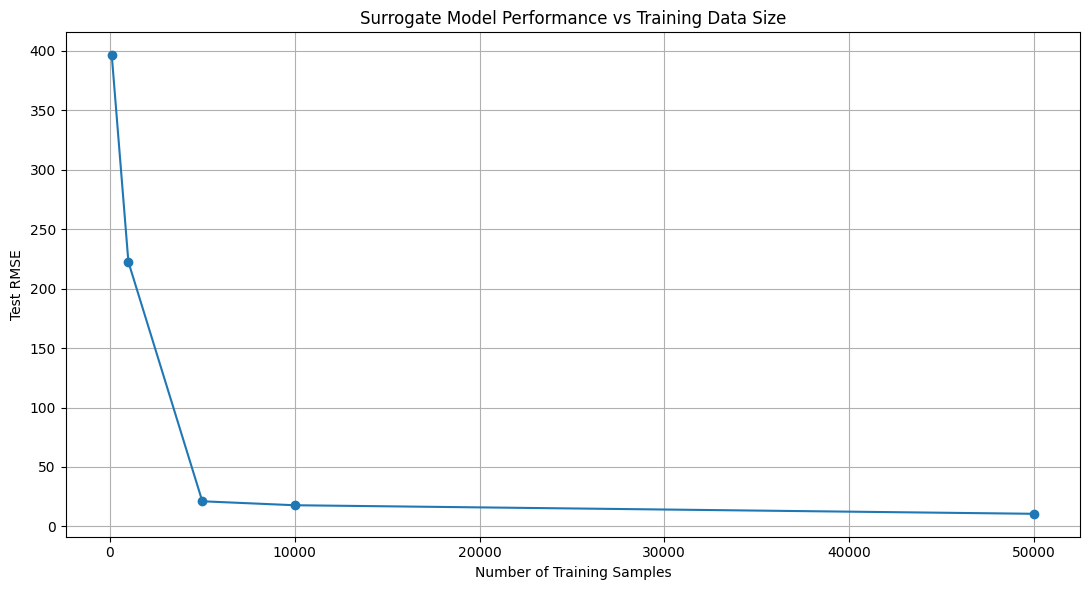

In [26]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(dataset_sizes, performance_scores, marker='o')
ax.set_xlabel("Number of Training Samples")
ax.set_ylabel("Test RMSE")
ax.set_title("Surrogate Model Performance vs Training Data Size")
ax.grid()
plt.tight_layout()
plt.show()

## Exercise 2: Optimization Robustness

**Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.

**Instructions:**
1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate's predicted values.



Testing on: Multimodal (f22): Gallagher's 21-hi Peaks

Surrogate Model MSE: 146.140738
  Completed optimization attempt 5/10
  Completed optimization attempt 10/10


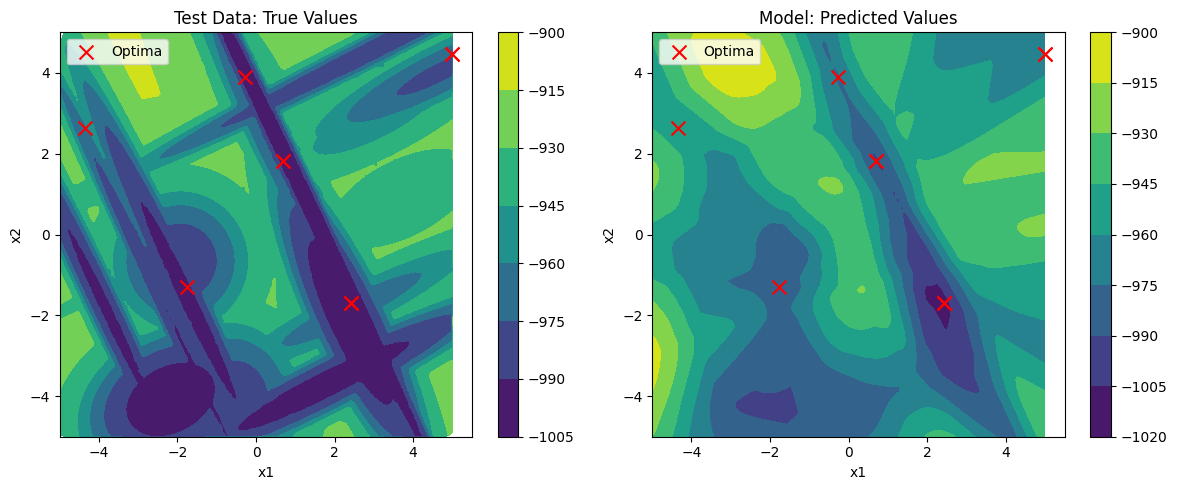


Testing on: Unimodal (f1): Sphere Function

Surrogate Model MSE: 0.066539
  Completed optimization attempt 5/10
  Completed optimization attempt 10/10


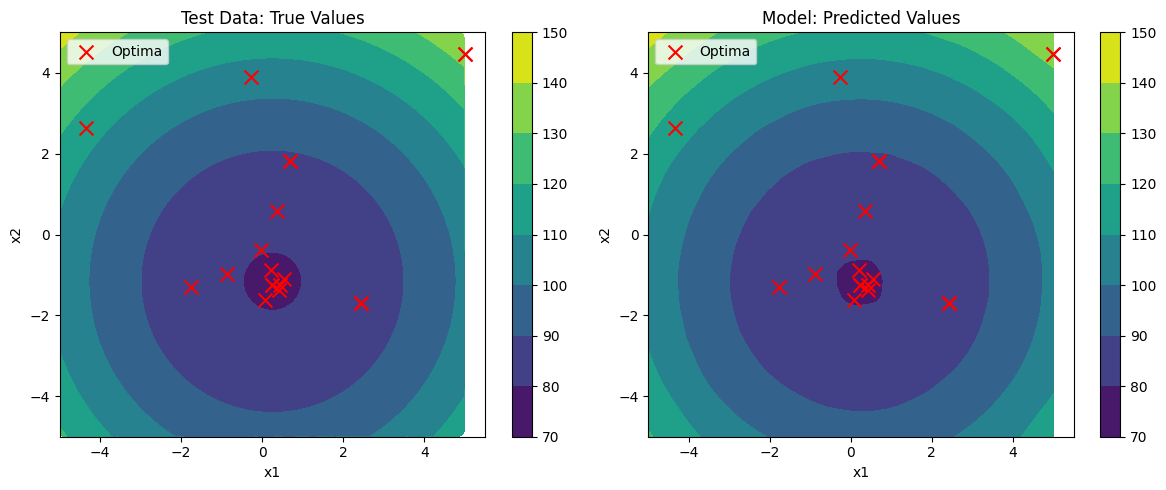

In [27]:
discovered_solutions = []
objective_values = []

function_datasets = [
    ("./bbob_f022_i01_d02_samples.csv", "Multimodal (f22): Gallagher's 21-hi Peaks"),
    ("./bbob_f001_i01_d02_samples.csv", "Unimodal (f1): Sphere Function")
]

num_optimization_attempts = 10

for data_file, function_description in function_datasets:
    print(f"\n{'='*65}")
    print(f"Testing on: {function_description}")
    print('='*65)

    train_dl, val_dl, test_dl = prepare_dataloaders(data_file, train_perc=0.3, val_perc=0.4)

    surrogate = MLP().to(device)
    loss_function = nn.MSELoss()
    surrogate_optimizer = torch.optim.Adam(surrogate.parameters(), lr=0.001)

    for training_epoch in range(100):
        surrogate.train()
        for X_batch, y_batch in train_dl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            surrogate_optimizer.zero_grad()
            y_pred = surrogate(X_batch)
            loss = loss_function(y_pred, y_batch)
            loss.backward()
            surrogate_optimizer.step()

    surrogate.eval()
    test_mse = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_dl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = surrogate(X_batch)
            loss = loss_function(y_pred, y_batch)
            test_mse += loss.item() * X_batch.size(0)

    test_mse /= len(test_dl.dataset)
    print(f"\nSurrogate Model MSE: {test_mse:.6f}")

    for attempt_num in range(num_optimization_attempts):
        optimal_x, optimal_y = optimize_model(surrogate, num_steps=500)
        discovered_solutions.append(optimal_x.cpu().numpy())
        objective_values.append(optimal_y)
        
        if (attempt_num + 1) % 5 == 0:
            print(f"  Completed optimization attempt {attempt_num + 1}/{num_optimization_attempts}")

    plot_contour_comparison(surrogate, test_dl, device, discovered_solutions)

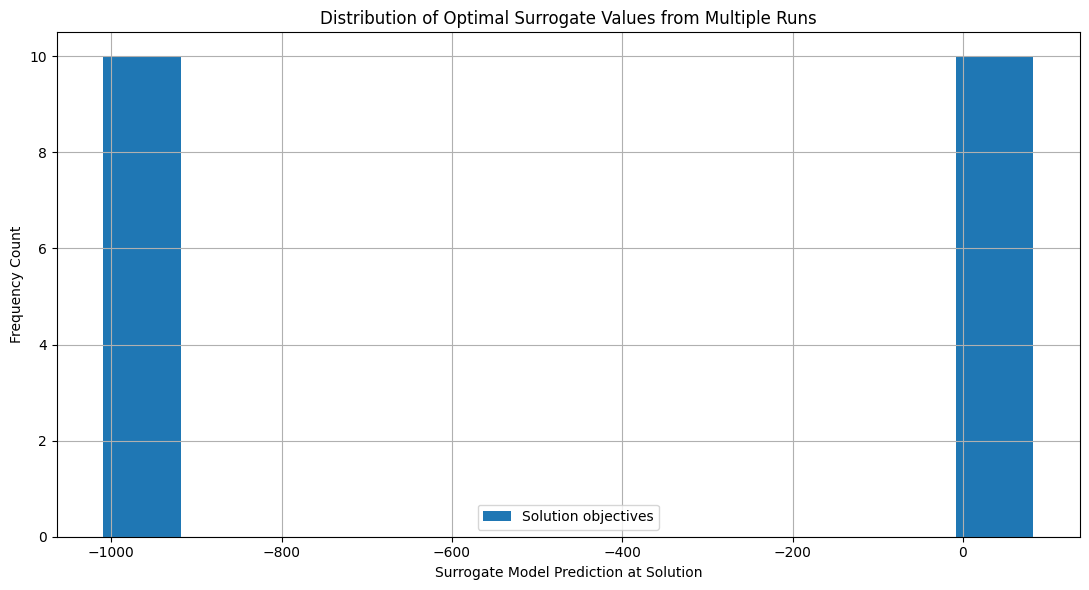

In [28]:
fig, axes = plt.subplots(figsize=(11, 6))
axes.hist(objective_values, bins=12, label='Solution objectives')
axes.set_xlabel("Surrogate Model Prediction at Solution")
axes.set_ylabel("Frequency Count")
axes.set_title("Distribution of Optimal Surrogate Values from Multiple Runs")
axes.grid()
axes.legend()
plt.tight_layout()
plt.show()


GROUND TRUTH VALIDATION: Comparing Surrogate to True Function

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Global optimum (true): f(0,0) = -936.0558

Detailed Comparison (first 10 solutions):

Solution   Surrogate       True Value      Error       
----------------------------------------------------
1          -1009.1108      -998.5864       10.5244     
2          -971.8105       -973.7807       1.9702      
3          -992.3152       -998.9855       6.6703      
4          -957.5860       -965.9527       8.3667      
5          -1009.1108      -998.5830       10.5278     
6          -992.3162       -999.0224       6.7062      
7          -1009.1117      -998.5550       10.5567     
8          -988.1115       -993.3163       5.2048      
9          -971.8105       -973.7567       1.9462      
10         -977.1194       -998.3779       21.2585     


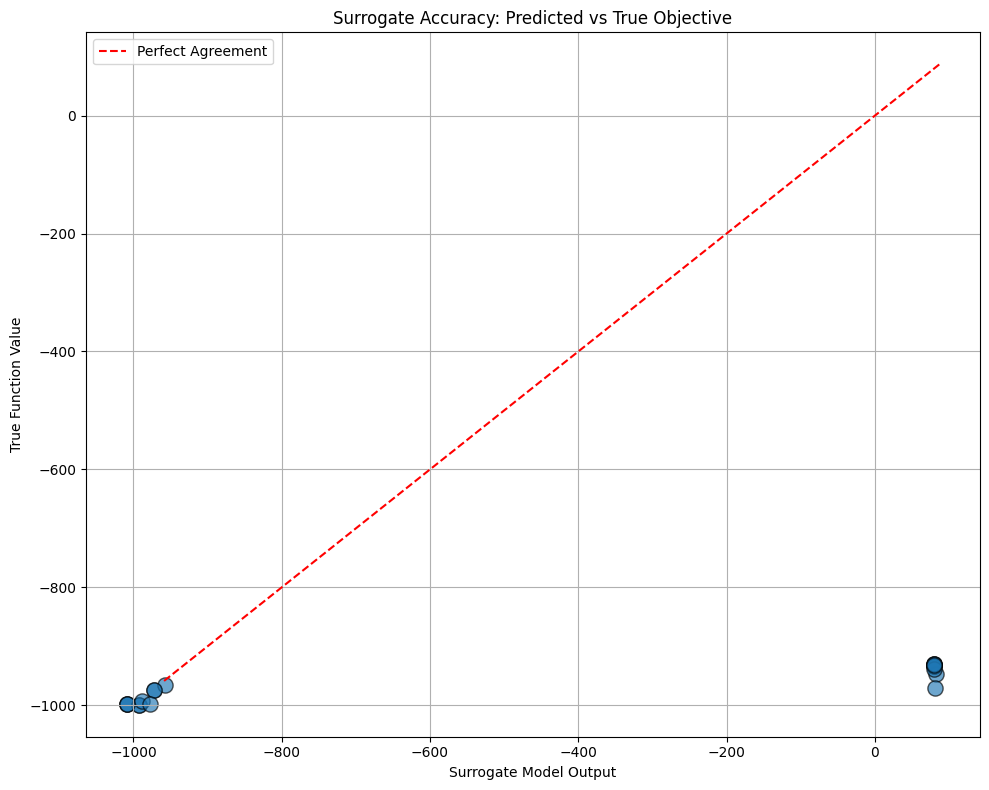

In [29]:
from cocoex import Suite

print("\n" + "="*70)
print("GROUND TRUTH VALIDATION: Comparing Surrogate to True Function")
print("="*70)

bench_function_id = 22

benchmark_suite = Suite("bbob", "", f"function_indices: {bench_function_id}, dimensions: 2 instance_indices: 1")

for true_function in benchmark_suite:
    print(f"\n{true_function.info}")
    print(f"Global optimum (true): f(0,0) = {true_function(np.array([0, 0])):.4f}\n")

    ground_truth_evaluations = []
    for solution_point in discovered_solutions:
        ground_truth_eval = true_function(solution_point.flatten())
        ground_truth_evaluations.append(ground_truth_eval)

    print("Detailed Comparison (first 10 solutions):\n")
    print(f"{'Solution':<10} {'Surrogate':<15} {'True Value':<15} {'Error':<12}")
    print("-" * 52)
    for idx in range(min(len(objective_values), 10)):
        error_magnitude = abs(objective_values[idx] - ground_truth_evaluations[idx])
        print(f"{idx+1:<10} {objective_values[idx]:<15.4f} {ground_truth_evaluations[idx]:<15.4f} {error_magnitude:<12.4f}")

    fig, axis = plt.subplots(figsize=(10, 8))
    axis.scatter(objective_values, ground_truth_evaluations, s=120, alpha=0.65, edgecolors='black', linewidth=1)
    
    all_predictions = objective_values + ground_truth_evaluations
    lower_bound = min(all_predictions) * 0.95
    upper_bound = max(all_predictions) * 1.05
    axis.plot([lower_bound, upper_bound], [lower_bound, upper_bound], 'r--', label='Perfect Agreement')
    
    axis.set_xlabel("Surrogate Model Output")
    axis.set_ylabel("True Function Value")
    axis.set_title("Surrogate Accuracy: Predicted vs True Objective")
    axis.legend()
    axis.grid()
    plt.tight_layout()
    plt.show()

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [30]:
! pip install coco-experiment cocopp

In [31]:
from cocoex import Suite

function_id = 22

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([0, 0])))

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844
